In [2]:
import numpy as np 
from sklearn.preprocessing import PolynomialFeatures

mobile_data = np.array([
   [4, 64],
    [6, 128],
    [8, 128],
    [8, 256],
    [12, 256] 
])

poly = PolynomialFeatures(degree=2)
poly_features = poly.fit_transform(mobile_data)

print("Feature names:", poly.get_feature_names_out(['RAM', 'Storage']))

print(poly_features)

Feature names: ['1' 'RAM' 'Storage' 'RAM^2' 'RAM Storage' 'Storage^2']
[[1.0000e+00 4.0000e+00 6.4000e+01 1.6000e+01 2.5600e+02 4.0960e+03]
 [1.0000e+00 6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]
 [1.0000e+00 8.0000e+00 1.2800e+02 6.4000e+01 1.0240e+03 1.6384e+04]
 [1.0000e+00 8.0000e+00 2.5600e+02 6.4000e+01 2.0480e+03 6.5536e+04]
 [1.0000e+00 1.2000e+01 2.5600e+02 1.4400e+02 3.0720e+03 6.5536e+04]]


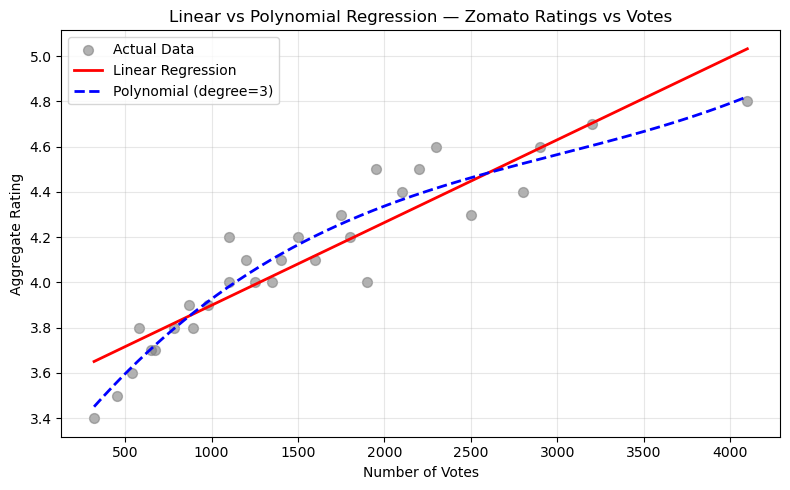

In [10]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

df = pd.read_csv('zomato_restaurants.csv')
df.head(2)

X = df['votes'].values.reshape(-1,1)
y = df['aggregate_rating'].values 

#model 

lin_model =LinearRegression()
lin_model.fit(X,y)

poly_model =Pipeline([
    ('poly' , PolynomialFeatures(degree=3)),
    ('linear' ,LinearRegression() )
])

poly_model.fit(X,y)

X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)


plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='gray', alpha=0.6, s=50, label='Actual Data')
plt.plot(X_smooth, lin_model.predict(X_smooth), color='red',  lw=2, label='Linear Regression')
plt.plot(X_smooth, poly_model.predict(X_smooth), color='blue', lw=2, linestyle='--', label='Polynomial (degree=3)')

plt.title('Linear vs Polynomial Regression — Zomato Ratings vs Votes')
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Degree 1 → Train MSE: 3,635,564 | Test MSE: 1,706,813
Degree 2 → Train MSE: 3,586,490 | Test MSE: 2,021,988
Degree 3 → Train MSE: 3,586,480 | Test MSE: 2,020,509
Degree 4 → Train MSE: 3,531,831 | Test MSE: 2,353,822
Degree 5 → Train MSE: 3,407,334 | Test MSE: 2,582,590


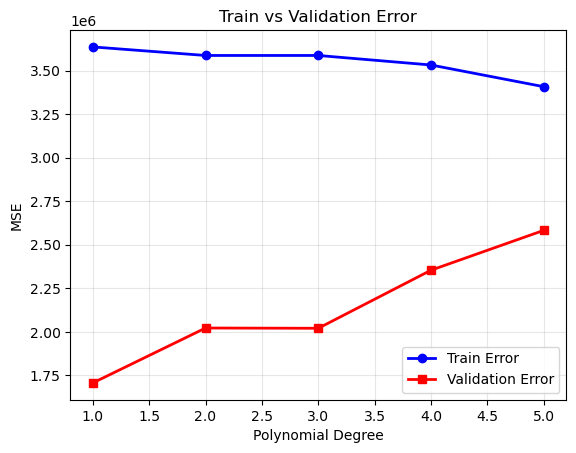

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv('instagram_data.csv')
df.head(2)

X = df['posts'].values.reshape(-1,1)
y = df['followers'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degrees = [1,2,3,4,5]
train_errors = []
test_errors= []

for d in degrees:
    model = Pipeline([
      ('poly',   PolynomialFeatures(degree=d)),
      ('linear', LinearRegression())  
    ])

    model.fit(X_train , y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(X_train)))
    test_errors.append(mean_squared_error(y_test,   model.predict(X_test)))
    print(f"Degree {d} → Train MSE: {train_errors[-1]:,.0f} | Test MSE: {test_errors[-1]:,.0f}")

plt.plot(degrees, train_errors, 'o-', color='blue', lw=2, label='Train Error')
plt.plot(degrees, test_errors,  's-', color='red',  lw=2, label='Validation Error')
plt.title('Train vs Validation Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv('flipkart_products.csv')

X = df[['num_reviews', 'rating', 'discount']].values
y = df['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Without Ridge
plain = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('scaler', StandardScaler()),
                  ('model', LinearRegression())])

# With Ridge
ridge = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('scaler', StandardScaler()),
                  ('model', Ridge(alpha=10.0))])

plain.fit(X_train, y_train)
ridge.fit(X_train, y_train)

print(f"Without Ridge → Test MSE: {mean_squared_error(y_test, plain.predict(X_test)):,.0f}")
print(f"With Ridge    → Test MSE: {mean_squared_error(y_test, ridge.predict(X_test)):,.0f}")

Without Ridge → Test MSE: 1,203,758
With Ridge    → Test MSE: 883,427
